In [21]:
# For a given sky position and frequency, compute the SNR for a point source with a given flux density.

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from pathlib import Path

%load_ext autoreload
%autoreload 2

from CHORD_Sensitivity import SkyMap
from CHORD_Sensitivity import Telescope
from CHORD_Sensitivity.constants import CLEAN_LINES

output_dir = Path("../../thesis/plots/sensitivity/")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
sky_map = SkyMap('CHORD')

nside = 1024
f = CLEAN_LINES

# Assume a uniform 10 mK peak line intensity across the sky at 1.5 GHz
f_0 = 1.5e9
x_0 = 10e-3  # 10 mK at 1.5 GHz
delta_nu = 5e3  # 5 kHz channel width
# Signal Map (This will be replaced by SIGMA data in future)
noise_sky_map = sky_map.sky_noise(delta_nu=delta_nu, freq=f, type='total_noise', CHORD_range=True)[0]
galactic_map = np.full(hp.nside2npix(nside), x_0, dtype=float)
galactic_map[np.isnan(noise_sky_map)] = np.nan

signal_map = np.empty((len(f), hp.nside2npix(nside)))
noise_map = np.empty_like(signal_map)
for i, freq in enumerate(f):
    scale_factor = f_0 / freq
    noise = sky_map.sky_noise(delta_nu=delta_nu, freq=freq, type='total_noise', CHORD_range=True)[0]*1e3
    signal_map[i] = galactic_map * scale_factor
    noise_map[i] = noise

SNR_map = signal_map / noise_map



In [23]:
import matplotlib.pyplot as plt
sm = SkyMap("CHORD")
noise = sm.sky_noise(delta_nu=delta_nu, freq=400, type='total_noise', CHORD_range=True)[0]*1e3  # Convert to mK
med = np.nanmedian(noise)
vmin = np.nanpercentile(noise, 0)
vmax = np.nanpercentile(noise, 99)

/opt/anaconda3/envs/rrl/lib/python3.10/site-packages/healpy/visufunc.py:200: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


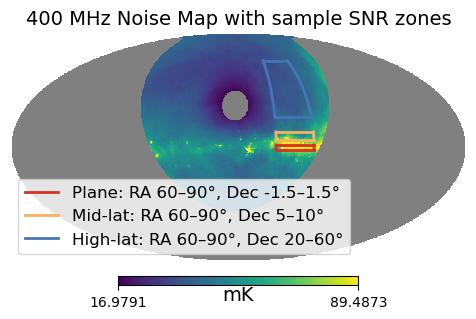

In [24]:
# Define sky zones, plot them on the noise map, and get the median noise per zone.
# Maps are stored in celestial coordinates (coord="C"), so the boxes below are RA/Dec ranges.
regions = {
    "Plane": {
        "dec": (-1.5, 1.5),
        "ra": (60, 90),
        "color": "#d73027",
    },
    "Mid-lat": {
        "dec": (5, 10),
        "ra": (60, 90),
        "color": "#fdae61",
    },
    "High-lat": {
        "dec": (20, 60),
        "ra": (60, 90),
        "color": "#4575b4",
    },
}

# Celestial (RA/Dec) coordinate of each pixel
npix = hp.nside2npix(nside)
theta, phi = hp.pix2ang(nside, np.arange(npix))
pix_dec = np.degrees(np.pi / 2 - theta)          # -90 .. +90
pix_ra = np.degrees(phi) % 360                   # 0 .. 360

## Plot the noise map with the zones drawn on it
plt.figure(figsize=(5, 3))
hp.mollview(
    noise,
    fig=1,
    coord="C",
    title="400 MHz Noise Map with sample SNR zones",
    unit='mK',
    cmap="viridis",
    cbar=True,
    min=vmin,
    max=vmax,
    notext=True,
    rot=(120, 0),
)
for label, box in regions.items():
    (d_min, d_max) = box["dec"]
    (r_min, r_max) = box["ra"]
    color = box["color"]
    legend_label = f"{label}: RA {r_min}–{r_max}°, Dec {d_min}–{d_max}°"
    # Only the first segment carries the legend label so each zone appears once.
    hp.projplot(np.full(100, r_min), np.linspace(d_min, d_max, 100), lonlat=True, color=color, lw=2, label=legend_label)
    hp.projplot(np.full(100, r_max), np.linspace(d_min, d_max, 100), lonlat=True, color=color, lw=2)
    hp.projplot(np.linspace(r_min, r_max, 100), np.full(100, d_min), lonlat=True, color=color, lw=2)
    hp.projplot(np.linspace(r_min, r_max, 100), np.full(100, d_max), lonlat=True, color=color, lw=2)
plt.legend(loc="lower left", fontsize=12)
plt.gca().title.set_fontsize(14)
plt.savefig(output_dir / "snr_locations.png", dpi=300, bbox_inches="tight")

In [25]:
plane_mask = (pix_dec >= regions["Plane"]["dec"][0]) & (pix_dec <= regions["Plane"]["dec"][1]) & \
             (pix_ra >= regions["Plane"]["ra"][0]) & (pix_ra <= regions["Plane"]["ra"][1])
mid_lat_mask = (pix_dec >= regions["Mid-lat"]["dec"][0]) & (pix_dec <= regions["Mid-lat"]["dec"][1]) & \
             (pix_ra >= regions["Mid-lat"]["ra"][0]) & (pix_ra <= regions["Mid-lat"]["ra"][1])
high_lat_mask = (pix_dec >= regions["High-lat"]["dec"][0]) & (pix_dec <= regions["High-lat"]["dec"][1]) & \
             (pix_ra >= regions["High-lat"]["ra"][0]) & (pix_ra <= regions["High-lat"]["ra"][1])



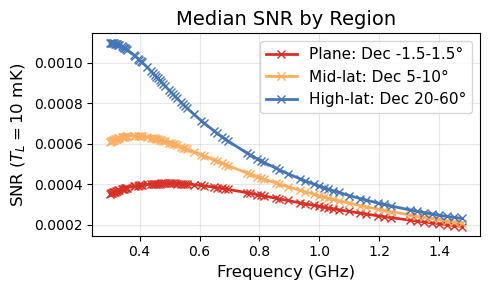

In [26]:
plane = np.nanmedian(SNR_map[:, plane_mask], axis=1)
mid_lat = np.nanmedian(SNR_map[:, mid_lat_mask], axis=1)
high_lat = np.nanmedian(SNR_map[:, high_lat_mask], axis=1)

plt.figure(figsize=(5, 3))
plt.plot(f / 1e9, plane, label='Plane: Dec -1.5-1.5°', linewidth=2, marker='x', color='#d73027')
plt.plot(f / 1e9, mid_lat, label='Mid-lat: Dec 5-10°', linewidth=2, marker='x', color='#fdae61')
plt.plot(f / 1e9, high_lat, label='High-lat: Dec 20-60°', linewidth=2, marker='x', color='#4575b4')
plt.xlabel('Frequency (GHz)', fontsize=12)
plt.ylabel('SNR ($T_L = 10$ mK)', fontsize=12)
plt.title('Median SNR by Region', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "snr_by_region.png", dpi=300, bbox_inches="tight")

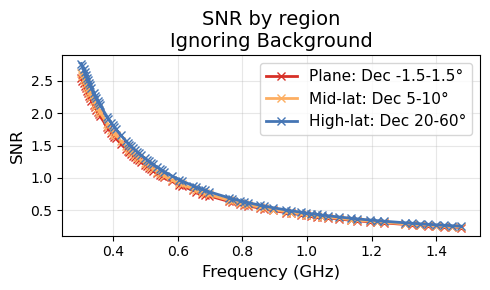

In [27]:
noise_sky_map = sky_map.sky_noise(delta_nu=delta_nu, freq=f, type='total_noise', CHORD_range=True)[0]
galactic_map = np.full(hp.nside2npix(nside), x_0, dtype=float)
galactic_map[np.isnan(noise_sky_map)] = np.nan

signal_map = np.empty((len(f), hp.nside2npix(nside)))
noise_map = np.empty_like(signal_map)
for i, freq in enumerate(f):
    scale_factor =  f_0 / freq
    noise = sky_map.sky_noise(delta_nu=delta_nu, freq=freq, type='system_only', CHORD_range=True)[0]
    signal_map[i] = galactic_map * scale_factor
    noise_map[i] = noise

SNR_map = signal_map / noise_map

plane = np.nanmedian(SNR_map[:, plane_mask], axis=1)
mid_lat = np.nanmedian(SNR_map[:, mid_lat_mask], axis=1)
high_lat = np.nanmedian(SNR_map[:, high_lat_mask], axis=1)

plt.figure(figsize=(5, 3))
plt.plot(f / 1e9, plane, label='Plane: Dec -1.5-1.5°', linewidth=2, marker='x', color='#d73027')
plt.plot(f / 1e9, mid_lat, label='Mid-lat: Dec 5-10°', linewidth=2, marker='x', color='#fdae61')
plt.plot(f / 1e9, high_lat, label='High-lat: Dec 20-60°', linewidth=2, marker='x', color='#4575b4')
plt.xlabel('Frequency (GHz)', fontsize=12)
plt.ylabel('SNR', fontsize=12)
plt.title('SNR by region\nIgnoring Background', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "snr_by_region_system_only.png", dpi=300, bbox_inches="tight")

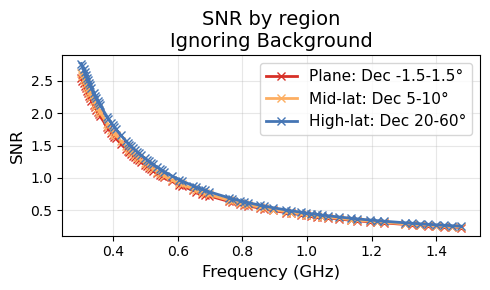

In [28]:
plt.figure(figsize=(5, 3))
plt.plot(f / 1e9, plane, label='Plane: Dec -1.5-1.5°', linewidth=2, marker='x', color='#d73027')
plt.plot(f / 1e9, mid_lat, label='Mid-lat: Dec 5-10°', linewidth=2, marker='x', color='#fdae61')
plt.plot(f / 1e9, high_lat, label='High-lat: Dec 20-60°', linewidth=2, marker='x', color='#4575b4')
plt.xlabel('Frequency (GHz)', fontsize=12)
plt.ylabel('SNR', fontsize=12)
plt.title('SNR by region\nIgnoring Background', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "snr_by_region_system_only.png", dpi=300, bbox_inches="tight")

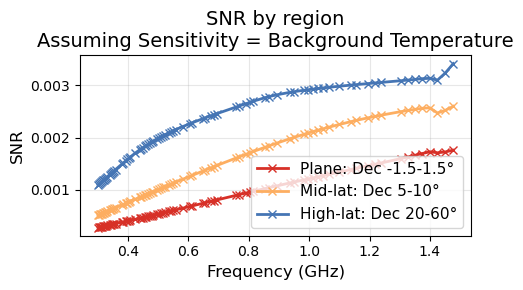

In [29]:
noise_sky_map = sky_map.sky_noise(delta_nu=delta_nu, freq=f, type='total_noise', CHORD_range=True)[0]
galactic_map = np.full(hp.nside2npix(nside), x_0, dtype=float)
galactic_map[np.isnan(noise_sky_map)] = np.nan

signal_map = np.empty((len(f), hp.nside2npix(nside)))
noise_map = np.empty_like(signal_map)
for i, freq in enumerate(f):
    scale_factor = f_0 / freq
    noise = sky_map.sky_noise(delta_nu=delta_nu, freq=freq, type='background_only', CHORD_range=True)[0]
    signal_map[i] = galactic_map * scale_factor
    noise_map[i] = noise

SNR_map_background = signal_map / noise_map

plane = np.nanmedian(SNR_map_background[:, plane_mask], axis=1)
mid_lat = np.nanmedian(SNR_map_background[:, mid_lat_mask], axis=1)
high_lat = np.nanmedian(SNR_map_background[:, high_lat_mask], axis=1)

plt.figure(figsize=(5, 3))
plt.plot(f / 1e9, plane, label='Plane: Dec -1.5-1.5°', linewidth=2, marker='x', color='#d73027')
plt.plot(f / 1e9, mid_lat, label='Mid-lat: Dec 5-10°', linewidth=2, marker='x', color='#fdae61')
plt.plot(f / 1e9, high_lat, label='High-lat: Dec 20-60°', linewidth=2, marker='x', color='#4575b4')
plt.xlabel('Frequency (GHz)', fontsize=12)
plt.ylabel('SNR', fontsize=12)
plt.title('SNR by region\nAssuming Sensitivity = Background Temperature', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "snr_by_region_background_only.png", dpi=300, bbox_inches="tight")

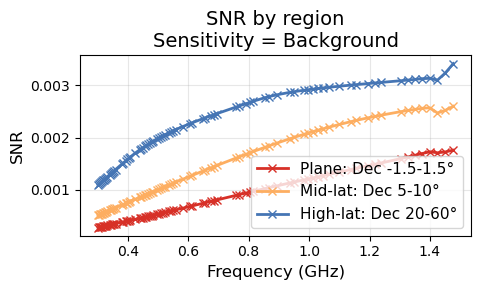

In [30]:
plt.figure(figsize=(5, 3))
plt.plot(f / 1e9, plane, label='Plane: Dec -1.5-1.5°', linewidth=2, marker='x', color='#d73027')
plt.plot(f / 1e9, mid_lat, label='Mid-lat: Dec 5-10°', linewidth=2, marker='x', color='#fdae61')
plt.plot(f / 1e9, high_lat, label='High-lat: Dec 20-60°', linewidth=2, marker='x', color='#4575b4')
plt.xlabel('Frequency (GHz)', fontsize=12)
plt.ylabel('SNR', fontsize=12)
plt.title('SNR by region\nSensitivity = Background', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "snr_by_region_background_only.png", dpi=300, bbox_inches="tight")

In [31]:
def radec_to_pix(ra_deg, dec_deg, nside=nside):
    ra_deg = ra_deg % 360.0
    dec_deg = np.clip(dec_deg, -90.0, 90.0)
    return hp.ang2pix(nside, ra_deg, dec_deg, lonlat=True)

# Example
ra_deg = 180.0
dec_deg = 30.0
pix_idx = radec_to_pix(ra_deg, dec_deg)

print("HEALPix pixel index:", pix_idx)

# If you want SNR at a specific frequency bin (example: closest to 1 GHz):
fi = np.argmin(np.abs(f - 1.0e9))
print("SNR at that sky position:", SNR_map[fi, pix_idx])

HEALPix pixel index: 3145728
SNR at that sky position: 0.4325713947145632
